# Insurance Dataset Analysis

In [44]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')


In [45]:
df = pd.read_csv(r'C:\Users\ADMIN\Documents\python\Eda Projects\Insurance\insurance.csv')

In [46]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA 

In [47]:
df.shape

(1338, 7)

In [48]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [50]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [51]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

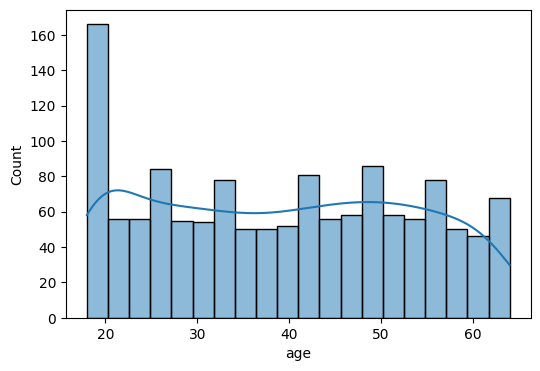

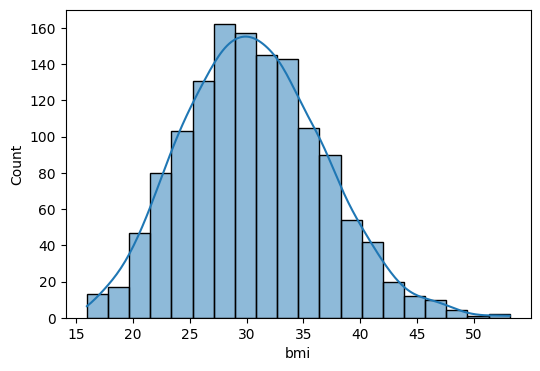

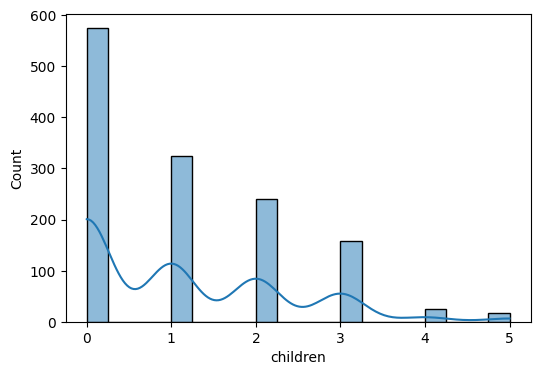

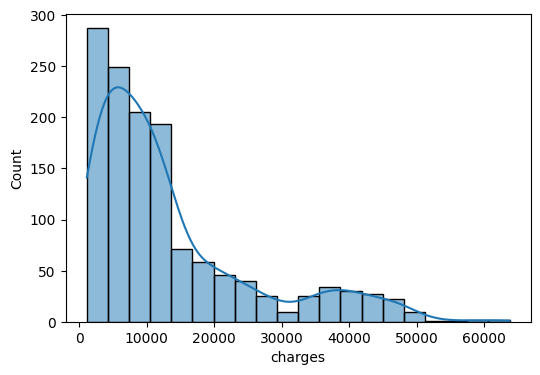

In [52]:
numeric_columns = ['age','bmi','children','charges']
for col in numeric_columns:
    plt.figure(figsize = (6,4))
    sns.histplot(df[col], kde = True ,bins = 20)
        

In [53]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

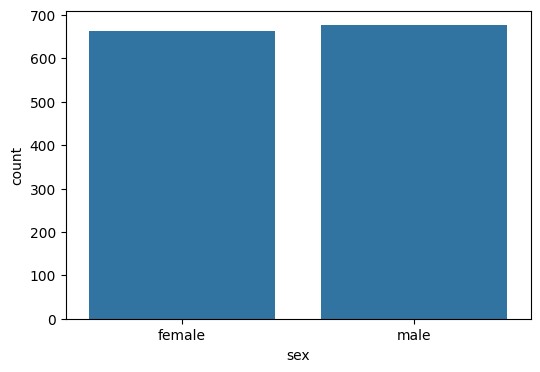

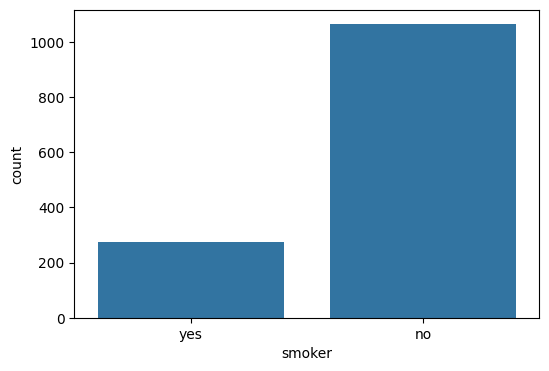

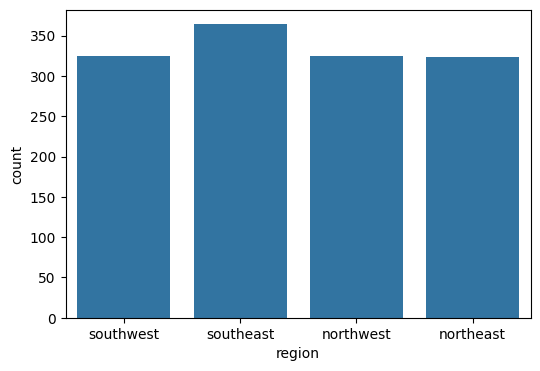

In [54]:
obj_cols = [ 'sex', 'smoker', 'region']
for cols in obj_cols:
    plt.figure(figsize = (6,4))
    sns.countplot(x = df[cols])

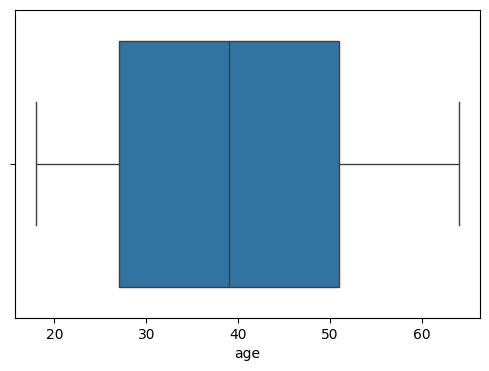

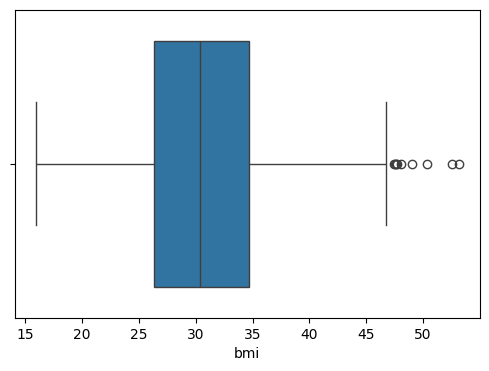

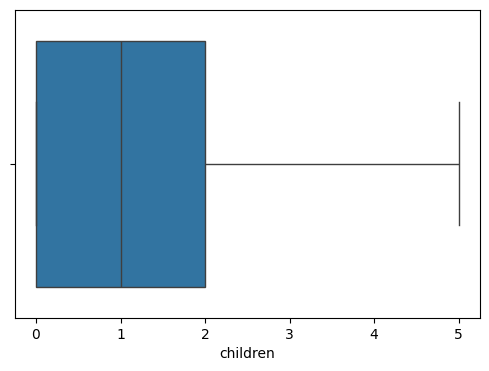

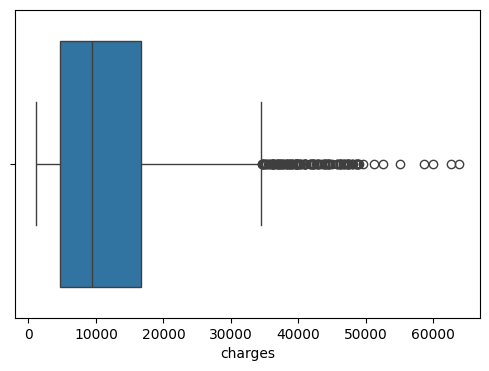

In [55]:
for col in numeric_columns:
    plt.figure(figsize = (6,4))
    sns.boxplot(x = df[col])

<Axes: xlabel='charges', ylabel='Count'>

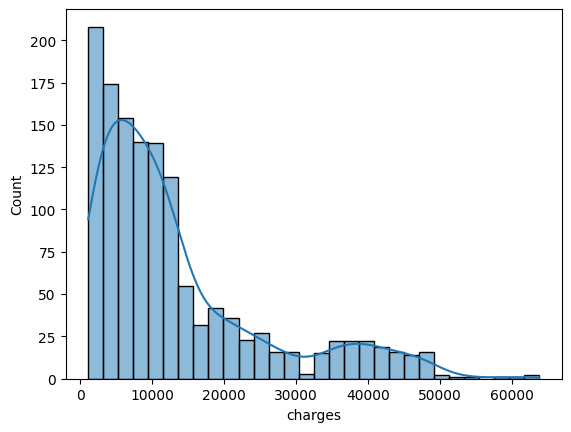

In [103]:
sns.histplot(df['charges'],kde = True)

<Axes: >

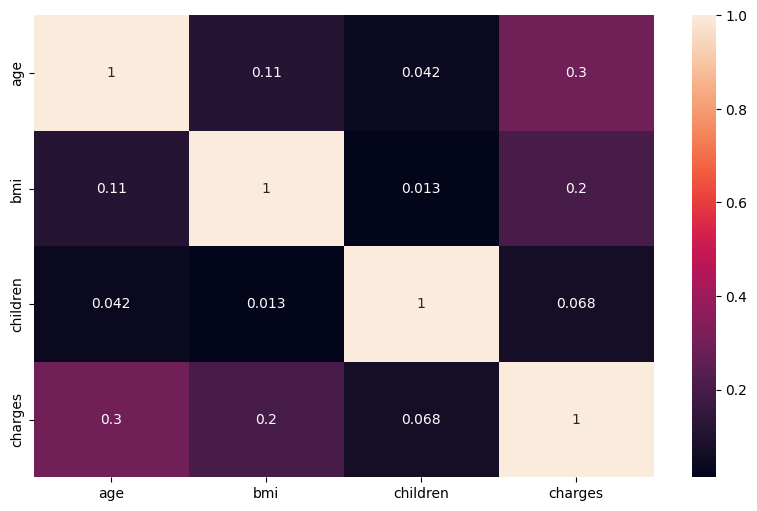

In [56]:
plt.figure(figsize = (10,6))
sns.heatmap(df.corr(numeric_only= True),annot= True)

# Data Cleaning & PreProcessing

In [57]:
df_cleaned = df.copy()

In [58]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [59]:
df_cleaned.drop_duplicates(inplace= True)

In [60]:
df_cleaned.shape

(1337, 7)

In [61]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [62]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [63]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [64]:
#Label enUnicoding
df_cleaned['sex'] = df_cleaned['sex'].map({'male' : 0 , 'female' : 1})

In [65]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [66]:
df_cleaned.head() # sex is now encoded to 0 and 1

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [67]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [68]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'no' : 0 , 'yes' : 1})


In [69]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [70]:
df_cleaned.rename(columns= {
    'sex' : 'is_female',
    'smoker' : 'is_smoker'
},inplace= True)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [71]:
df_cleaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [72]:
df_cleaned = pd.get_dummies(df_cleaned,columns= ['region'],drop_first= True)

In [73]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [74]:
df_cleaned.astype(int)

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


# Feature Engineering  and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

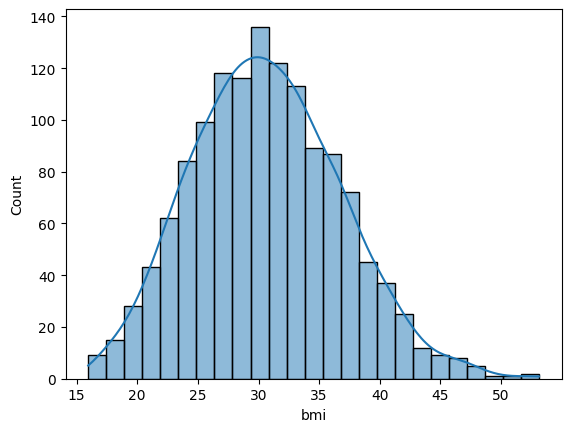

In [75]:
sns.histplot(df['bmi'] ,kde= True)

In [76]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'] , 
    bins = [0,18.5,24.9,29.9,float('inf')] , 
    labels= ['Underweight','Normal','Overweight','Obese']
    
)

In [77]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,False,False,True,Overweight
1,18,0,33.770,1,0,1725.55230,False,True,False,Obese
2,28,0,33.000,3,0,4449.46200,False,True,False,Obese
3,33,0,22.705,0,0,21984.47061,True,False,False,Normal
4,32,0,28.880,0,0,3866.85520,True,False,False,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False,Obese
1334,18,1,31.920,0,0,2205.98080,False,False,False,Obese
1335,18,1,36.850,0,0,1629.83350,False,True,False,Obese
1336,21,1,25.800,0,0,2007.94500,False,False,True,Overweight


In [78]:
# One-hot encoding
df_cleaned = pd.get_dummies(
    df_cleaned,
    columns=['bmi_category'],
    drop_first=True
)


In [79]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27.900,0,1,16884.92400,False,False,True,False,True,False
1,18,0,33.770,1,0,1725.55230,False,True,False,False,False,True
2,28,0,33.000,3,0,4449.46200,False,True,False,False,False,True
3,33,0,22.705,0,0,21984.47061,True,False,False,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False,False,False,True
1334,18,1,31.920,0,0,2205.98080,False,False,False,False,False,True
1335,18,1,36.850,0,0,1629.83350,False,True,False,False,False,True
1336,21,1,25.800,0,0,2007.94500,False,False,True,False,True,False


In [80]:
df_cleaned = df_cleaned.astype(int)

In [81]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [82]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

In [83]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [84]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,1,0,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,0,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,0,1,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0,1,0,1,0


In [85]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

In [86]:
from scipy.stats import pearsonr

selected_features = ['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]
correlations = {
    feature : pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns= ['feature','Pearson Correlation'])
correlation_df.sort_values(by = 'Pearson Correlation' , ascending = False)

,feature,Pearson Correlation
5,charges,1.000000
4,is_smoker,0.787234
0,age,0.298309
11,bmi_category_Obese,0.197660
2,bmi,0.196236
7,region_southeast,0.073577
3,children,0.067390
6,region_northwest,-0.038695
8,region_southwest,-0.043637
1,is_female,-0.058046


In [87]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

In [98]:
cat_features =cat_features = [
    'is_female',
    'is_smoker',
    'region_northwest',
    'region_southeast',
    'region_southwest',
    'bmi_category_Normal',
    'bmi_category_Overweight',
    'bmi_category_Obese'
]

In [99]:
from scipy.stats import chi2_contingency
alpha = 0.05
df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'] , q = 4 , labels= False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val , _,_ = chi2_contingency(contingency)
    decision = 'Reject Null(Keep feature)' if p_val < alpha else 'Accept Null (Drop feature)'
    chi2_results[col] = {
        'chi2_statistics' :chi2_stat, 
        'p_value' : p_val, 
        'Decision' : decision
    }
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by = 'p_value')
chi2_df

,chi2_statistics,p_value,Decision
is_smoker,848.219178,0.0,Reject Null(Keep feature)
region_southeast,15.998167,0.001135,Reject Null(Keep feature)
is_female,10.258784,0.01649,Reject Null(Keep feature)
bmi_category_Obese,7.654464,0.05372,Accept Null (Drop feature)
region_southwest,5.091893,0.165191,Accept Null (Drop feature)
bmi_category_Normal,4.263673,0.234364,Accept Null (Drop feature)
bmi_category_Overweight,4.201575,0.240504,Accept Null (Drop feature)
region_northwest,1.13424,0.768815,Accept Null (Drop feature)


In [100]:
final_df = df_cleaned[['age','is_smoker','children','region_southeast','is_female','bmi','charges']]

In [101]:
final_df

,age,is_smoker,children,region_southeast,is_female,bmi,charges
0,-1.440418,1,-0.909234,0,1,-0.517949,16884
1,-1.511647,0,-0.079442,1,0,0.462463,1725
2,-0.799350,0,1.580143,1,0,0.462463,4449
3,-0.443201,0,-0.909234,0,0,-1.334960,21984
4,-0.514431,0,-0.909234,0,0,-0.354547,3866
...,...,...,...,...,...,...,...
1333,0.767704,0,1.580143,0,0,-0.027743,10600
1334,-1.511647,0,-0.909234,0,1,0.135659,2205
1335,-1.511647,0,-0.909234,1,1,0.952670,1629
1336,-1.297958,0,-0.909234,0,1,-0.844753,2007


# Business Insights

## 1. Smoking is the strongest driver of insurance charges
Smokers incur significantly higher medical costs than non-smokers, making smoking status the most influential factor affecting insurance premiums.

## 2. Age positively impacts insurance costs
Older customers generally have higher medical expenses, indicating increased health risks with age.

## 3. BMI contributes to higher charges
Customers classified as overweight or obese tend to incur greater insurance expenses compared to those with normal BMI.

## 4. Region has limited impact
Insurance charges remain relatively consistent across different regions, suggesting geographic location is not a major pricing factor.


## 5. High-risk customer segments
Older smokers with high BMI represent the highest-cost group and should be prioritized for preventive healthcare programs.


# Business Recommendations

- Introduce wellness incentives for non-smokers.
- Promote preventive health programs for overweight customers.
- Implement risk-based pricing strategies.
- Develop predictive models for early identification of high-cost customers.

# Conclusion

The analysis identified smoking status, age, and BMI as the primary drivers of medical insurance charges. Smoking emerged as the most significant factor, followed by age and BMI. Regional and gender differences showed comparatively lower influence on insurance costs. These findings can support better risk assessment, premium pricing, and customer health management strategies.